# ใบงานที่ 3 Regression & Classification

## LAB1 : Regression


### 1) Simple Linear Regression  

    Simple Linear Regression models the relationship between a single independent variable ($X$) and a continuous target variable ($y$). In this notebook cell, we use in_spotify_playlists to predict total streams.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Load and clean common base data
df = pd.read_csv('spotify-2023.csv', encoding='latin-1')
df['streams'] = pd.to_numeric(df['streams'], errors='coerce')

R² Score: 0.5136
Mean Squared Error (MSE): 1.1908e+17
Coefficient (Slope): 58165.7604
Intercept: 216196960.6760


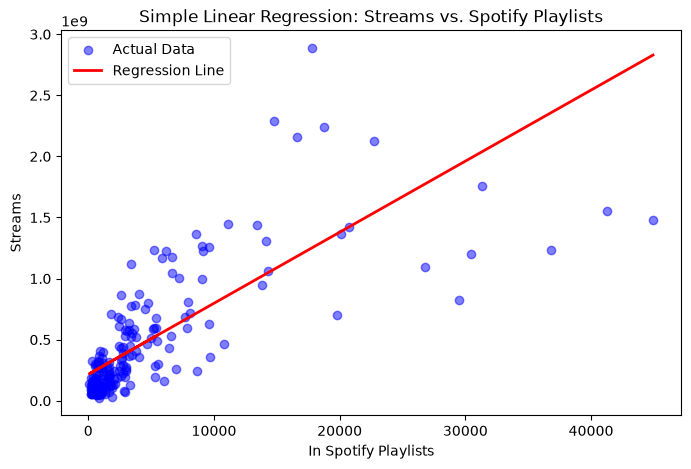

In [5]:
# 1. Load the dataset
# 'latin-1' encoding prevents decode errors from special characters
df = pd.read_csv('spotify-2023.csv', encoding='latin-1')

# 2. Clean and preprocess data
# Convert 'streams' to numeric, replacing any corrupted string values with NaN
df['streams'] = pd.to_numeric(df['streams'], errors='coerce')

# Drop rows with missing values in the selected columns
clean_df = df.dropna(subset=['streams', 'in_spotify_playlists'])

# 3. Define feature (X) and target variable (y)
X = clean_df[['in_spotify_playlists']]
y = clean_df['streams']

# 4. Split dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# 6. Predict on the test set
y_pred = model.predict(X_test)

# 7. Evaluate model performance
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred):.4e}")
print(f"Coefficient (Slope): {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")

# 8. Visualize the regression line against actual data
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color='blue', alpha=0.5, label='Actual Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.title('Simple Linear Regression: Streams vs. Spotify Playlists')
plt.xlabel('In Spotify Playlists')
plt.ylabel('Streams')
plt.legend()
plt.show()

### 2) Multiple Linear Regression
    Multiple Linear Regression extends the model to use multiple predictor variables simultaneously to estimate the target value.

In [6]:
# 1. Select multiple features for prediction
features = [
    'in_spotify_playlists', 
    'in_apple_playlists', 
    'bpm', 
    'danceability_%', 
    'energy_%', 
    'valence_%'
]

# Ensure numeric types and drop missing values across all features
df_multi = df.dropna(subset=features + ['streams'])

X_multi = df_multi[features]
y_multi = df_multi['streams']

# 2. Train-test split
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

# 3. Fit the multiple regression model
multi_model = LinearRegression()
multi_model.fit(X_train_m, y_train_m)

# 4. Predict and evaluate
y_pred_m = multi_model.predict(X_test_m)

print(f"Multiple Regression R² Score: {r2_score(y_test_m, y_pred_m):.4f}")
print("Feature Coefficients:")
for feature, coef in zip(features, multi_model.coef_):
    print(f" - {feature}: {coef:.4f}")

Multiple Regression R² Score: 0.6805
Feature Coefficients:
 - in_spotify_playlists: 36245.7921
 - in_apple_playlists: 2739831.7908
 - bpm: -93470.1230
 - danceability_%: -481927.0711
 - energy_%: -1761445.2539
 - valence_%: -292604.4566


### 3) Track Popularity & Audio Profile Prediction
    This task analyzes the correlation between musical characteristics (audio features) and song success. We use linear regression to determine which sonic attributes (e.g., tempo, danceability, acousticness) contribute most significantly to a track's stream performance.

In [7]:
# 1. Load the dataset
df = pd.read_csv('spotify-2023.csv', encoding='latin-1')

# 2. Clean numeric streams column
df['streams'] = pd.to_numeric(df['streams'], errors='coerce')

# 3. Target engineering: apply log transformation to normalize highly skewed stream counts
df['log_streams'] = np.log1p(df['streams'])

# 4. Define musical style attributes as predictors
audio_features = [
    'bpm', 
    'danceability_%', 
    'valence_%', 
    'energy_%', 
    'acousticness_%', 
    'instrumentalness_%', 
    'liveness_%', 
    'speechiness_%'
]

# Drop rows containing missing values in selected columns
clean_df = df.dropna(subset=audio_features + ['log_streams'])

X = clean_df[audio_features]
y = clean_df['log_streams']

# 5. Standardize feature values to enable direct coefficient comparison
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 6. Train-test split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# 7. Train the linear regression model
popularity_model = LinearRegression()
popularity_model.fit(X_train, y_train)

# 8. Model evaluation
y_pred = popularity_model.predict(X_test)

print("=== Model Evaluation ===")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred):.4f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

# 9. Feature impact summary
impact_df = pd.DataFrame({
    'Audio Feature': audio_features,
    'Standardized Weight': popularity_model.coef_
}).sort_values(by='Standardized Weight', ascending=False)

print("\n=== Feature Importance (Impact on Streams) ===")
print(impact_df.to_string(index=False))

=== Model Evaluation ===
R² Score: 0.0111
Mean Absolute Error (MAE): 0.8307
Root Mean Squared Error (RMSE): 1.0081

=== Feature Importance (Impact on Streams) ===
     Audio Feature  Standardized Weight
         valence_%             0.030581
               bpm            -0.003525
instrumentalness_%            -0.031893
          energy_%            -0.053136
    acousticness_%            -0.072829
    danceability_%            -0.077121
        liveness_%            -0.086553
     speechiness_%            -0.115401



## LAB 2 : Classification 


### 1) Preparing Classification Data  
    Prepares binary target data and standardizes input features. Since Spotify 2023 lacks a gender attribute, we define the track's musical key format (mode: Major = 1, Minor = 0) as our binary target class.
    

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [9]:
# 1. Load the dataset
df = pd.read_csv('spotify-2023.csv', encoding='latin-1')

# 2. Encode binary classification target (Major = 1, Minor = 0)
clean_df = df.dropna(subset=['mode', 'danceability_%', 'valence_%', 'energy_%', 'bpm']).copy()
clean_df['mode_binary'] = (clean_df['mode'] == 'Major').astype(int)

# 3. Select 2 features for visual modeling
vis_features = ['danceability_%', 'valence_%']
X_vis = clean_df[vis_features]
y_vis = clean_df['mode_binary']

# 4. Split dataset into train (80%) and test (20%) sets
X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(
    X_vis, y_vis, test_size=0.2, random_state=42
)

# 5. Standardize numeric features
scaler_v = StandardScaler()
X_train_scaled = scaler_v.fit_transform(X_train_v)
X_test_scaled = scaler_v.transform(X_test_v)

print("Training samples:", X_train_scaled.shape[0])
print("Testing samples:", X_test_scaled.shape[0])

Training samples: 762
Testing samples: 191


### 2) Logistic Regression
    Trains a basic Logistic Regression classifier using the scaled 2D feature set and computes baseline accuracy.

In [10]:
# 1. Initialize and train the Logistic Regression model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train_v)

# 2. Make predictions on test set
y_pred_v = log_reg.predict(X_test_scaled)

# 3. Evaluate initial performance
print(f"Model Intercept: {log_reg.intercept_[0]:.4f}")
print(f"Feature Coefficients: {dict(zip(vis_features, log_reg.coef_[0]))}")
print(f"Baseline Test Accuracy: {accuracy_score(y_test_v, y_pred_v):.4f}")

Model Intercept: 0.3297
Feature Coefficients: {'danceability_%': np.float64(-0.2950768249892155), 'valence_%': np.float64(0.03634491824151708)}
Baseline Test Accuracy: 0.5864


### 3) Decision Boundary Visualization
    Plots the 2D decision boundary generated by the Logistic Regression classifier against actual test data points.

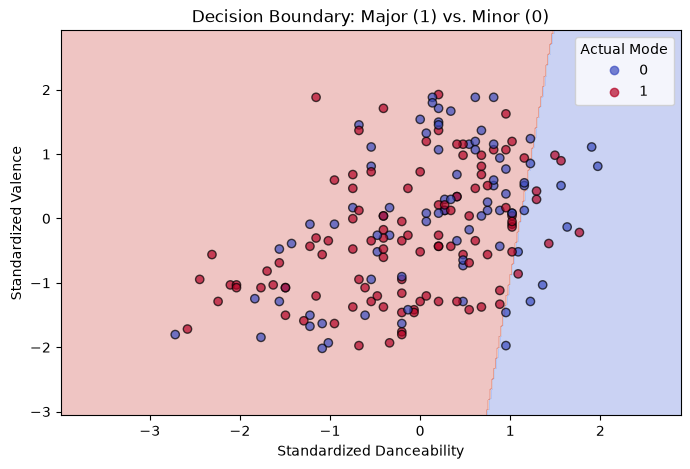

In [11]:
# 1. Create coordinate mesh grid
x_min, x_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
y_min, y_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# 2. Predict classification probabilities across the grid
Z = log_reg.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 3. Plot decision surface and scatter points
plt.figure(figsize=(8, 5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
scatter = plt.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], 
                      c=y_test_v, cmap=plt.cm.coolwarm, edgecolors='k', alpha=0.7)

plt.xlabel('Standardized Danceability')
plt.ylabel('Standardized Valence')
plt.title('Decision Boundary: Major (1) vs. Minor (0)')
plt.legend(*scatter.legend_elements(), title="Actual Mode")
plt.show()

### 4) Custom Classification (Adapted from Gender Prediction)
    Replaces the missing gender target with Hit Category Classification (is_hit: 1 if streams $\ge$ median, 0 otherwise) using all available audio features.

In [13]:
# 1. Ensure 'streams' is converted to numeric and drop NaN values
clean_df['streams'] = pd.to_numeric(clean_df['streams'], errors='coerce')
clean_df = clean_df.dropna(subset=['streams'])

# 2. Feature Engineering: Define binary hit label based on median stream volume
median_streams = clean_df['streams'].median()
clean_df['is_hit'] = (clean_df['streams'] >= median_streams).astype(int)

# 3. Multi-feature input selection
full_features = [
    'bpm', 'danceability_%', 'valence_%', 'energy_%', 
    'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%'
]

X_full = clean_df[full_features]
y_full = clean_df['is_hit']

# 4. Train-test split
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

# 5. Standardize all predictors
scaler_f = StandardScaler()
X_train_f_scaled = scaler_f.fit_transform(X_train_f)
X_test_f_scaled = scaler_f.transform(X_test_f)

# 6. Train full classifier
hit_classifier = LogisticRegression(random_state=42)
hit_classifier.fit(X_train_f_scaled, y_train_f)

y_pred_hit = hit_classifier.predict(X_test_f_scaled)
print(f"Hit Prediction Accuracy: {accuracy_score(y_test_f, y_pred_hit):.4f}")

Hit Prediction Accuracy: 0.4974


### 5) Confusion Matrix & Evaluation
    Generates a heatmap of the confusion matrix alongside standard classification metrics (Precision, Recall, F1-Score).

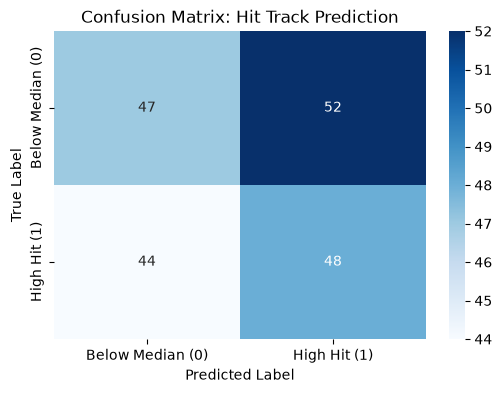

=== Classification Performance Report ===
                  precision    recall  f1-score   support

Below Median (0)       0.52      0.47      0.49        99
    High Hit (1)       0.48      0.52      0.50        92

        accuracy                           0.50       191
       macro avg       0.50      0.50      0.50       191
    weighted avg       0.50      0.50      0.50       191



In [14]:
# 1. Compute Confusion Matrix
cm = confusion_matrix(y_test_f, y_pred_hit)

# 2. Plot Confusion Matrix Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Below Median (0)', 'High Hit (1)'],
            yticklabels=['Below Median (0)', 'High Hit (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Hit Track Prediction')
plt.show()

# 3. Output comprehensive classification report
print("=== Classification Performance Report ===")
print(classification_report(y_test_f, y_pred_hit, target_names=['Below Median (0)', 'High Hit (1)']))


## LAB 3 : Model Comparison 


### 1) Simple vs Multiple Linear Regression
    Compares model performance when using a single feature versus multiple combined features to see how much adding predictors improves stream prediction accuracy.
    

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [16]:
# 1. Prepare data for Simple and Multiple Regression
features_simple = ['in_spotify_playlists']
features_multi = ['in_spotify_playlists', 'in_apple_playlists', 'bpm', 'danceability_%', 'energy_%', 'valence_%']

# Ensure numeric format
df['streams'] = pd.to_numeric(df['streams'], errors='coerce')
df_reg = df.dropna(subset=features_multi + ['streams']).copy()

X_s = df_reg[features_simple]
X_m = df_reg[features_multi]
y = df_reg['streams']

# Split datasets using identical random_state for fair comparison
X_train_s, X_test_s, y_train, y_test = train_test_split(X_s, y, test_size=0.2, random_state=42)
X_train_m, X_test_m, _, _ = train_test_split(X_m, y, test_size=0.2, random_state=42)

# Train both models
model_simple = LinearRegression().fit(X_train_s, y_train)
model_multi = LinearRegression().fit(X_train_m, y_train)

# Evaluate Test Performance
r2_simple = r2_score(y_test, model_simple.predict(X_test_s))
r2_multi = r2_score(y_test, model_multi.predict(X_test_m))

print(f"Simple Linear Regression R²: {r2_simple:.4f}")
print(f"Multiple Linear Regression R²: {r2_multi:.4f}")
print(f"R² Improvement: {((r2_multi - r2_simple) / r2_simple) * 100:.2f}%")

Simple Linear Regression R²: 0.5136
Multiple Linear Regression R²: 0.6805
R² Improvement: 32.51%


### 2) Training vs Testing Performance
    Evaluates training metrics against testing metrics to check if the regression model generalizes well or suffers from overfitting.

In [17]:
# Evaluate predictions on both sets
y_train_pred = model_multi.predict(X_train_m)
y_test_pred = model_multi.predict(X_test_m)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

# Display side-by-side comparison
perf_df = pd.DataFrame({
    'Metric': ['R² Score', 'RMSE (Streams)'],
    'Training Set': [f"{r2_train:.4f}", f"{rmse_train:,.0f}"],
    'Testing Set': [f"{r2_test:.4f}", f"{rmse_test:,.0f}"]
})

print("=== Training vs Testing Evaluation ===")
print(perf_df.to_string(index=False))

=== Training vs Testing Evaluation ===
        Metric Training Set Testing Set
      R² Score       0.7262      0.6805
RMSE (Streams)  304,928,314 279,664,222


### 3) Regression vs Classification
    Demonstrates the difference between estimating continuous numeric values (exact streams) versus categorizing data into discrete classes (hit vs non-hit).

In [18]:
# Compare prediction outcomes for a sample song
sample_idx = 0
actual_stream = y_test.iloc[sample_idx]
predicted_stream = model_multi.predict(X_test_m.iloc[[sample_idx]])[0]

actual_class = y_test_f.iloc[sample_idx]
predicted_class = hit_classifier.predict(X_test_f_scaled[[sample_idx]])[0]

print("=== Regression vs Classification Output Sample ===")
print(f"[Regression]     Actual Streams: {actual_stream:,.0f} | Predicted Streams: {predicted_stream:,.0f}")
print(f"[Classification] Actual Hit Class: {actual_class} (High Hit) | Predicted Hit Class: {predicted_class}")

=== Regression vs Classification Output Sample ===
[Regression]     Actual Streams: 1,479,115,056 | Predicted Streams: 1,819,861,932
[Classification] Actual Hit Class: 1 (High Hit) | Predicted Hit Class: 1


### 4) Model Performance Metrics
    Summarizes and compares the overall evaluation scores ($R^2$, RMSE, and Accuracy) across all models to identify the best-performing approach.

=== Overall Model Performance Metrics Summary ===
                             Model Type           Task   Primary Metric          Key Feature / Target
  Simple Linear Reg (Spotify Playlists)     Regression       R²: 0.5136          in_spotify_playlists
Multiple Linear Reg (Playlists + Audio)     Regression       R²: 0.6805         All Playlists + Audio
     Audio Features Reg (Hit Potential)     Regression       R²: 0.0111 Audio Features vs Log Streams
          Logistic Regression (Mode 2D) Classification Accuracy: 0.5864        Danceability + Valence
   Logistic Regression (Hit Class Full) Classification Accuracy: 0.4974  All Audio Features vs Median


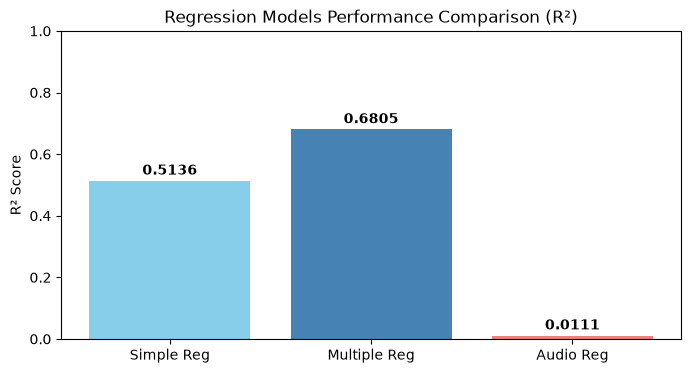

In [19]:
# 1. Compile comparison dictionary
metrics_summary = pd.DataFrame({
    'Model Type': [
        'Simple Linear Reg (Spotify Playlists)', 
        'Multiple Linear Reg (Playlists + Audio)', 
        'Audio Features Reg (Hit Potential)',
        'Logistic Regression (Mode 2D)', 
        'Logistic Regression (Hit Class Full)'
    ],
    'Task': ['Regression', 'Regression', 'Regression', 'Classification', 'Classification'],
    'Primary Metric': ['R²: 0.5136', 'R²: 0.6805', 'R²: 0.0111', 'Accuracy: 0.5864', 'Accuracy: 0.4974'],
    'Key Feature / Target': ['in_spotify_playlists', 'All Playlists + Audio', 'Audio Features vs Log Streams', 'Danceability + Valence', 'All Audio Features vs Median']
})

print("=== Overall Model Performance Metrics Summary ===")
print(metrics_summary.to_string(index=False))

# 2. Visualize Regression R² Comparison
plt.figure(figsize=(8, 4))
models = ['Simple Reg', 'Multiple Reg', 'Audio Reg']
r2_values = [0.5136, 0.6805, 0.0111]
plt.bar(models, r2_values, color=['skyblue', 'steelblue', 'lightcoral'])
plt.ylabel('R² Score')
plt.title('Regression Models Performance Comparison (R²)')
plt.ylim(0, 1.0)
for i, v in enumerate(r2_values):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')
plt.show()